# HAR Datasets — Merge

Merges UCI HAR, WISDM, MotionSense, HHAR into a single `(n_windows, 128, 3)` array.

**Strategy:**
- Sensor: accelerometer (x, y, z) only — the one modality all four datasets share
- Resampling: everything → 50 Hz (UCI HAR & MotionSense already at 50 Hz; WISDM ~20 Hz upsampled; HHAR 100-200 Hz downsampled)
- Windowing: 128 samples, 50 % overlap (step = 64)
- Labels: 5 common classes — `walk`, `upstairs`, `downstairs`, `sit`, `stand`
- Output: `data/merged/har_merged.npz` — arrays `X`, `y`, `activity`, `subject`, `source`

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

DATA_DIR = Path("data")
OUT_DIR  = DATA_DIR / "merged"
OUT_DIR.mkdir(exist_ok=True)

WINDOW    = 128
STEP      = 64
TARGET_HZ = 50
COMMON_ACT = ["walk", "upstairs", "downstairs", "sit", "stand"]

CANON = {
    "uci":         {"WALKING": "walk", "WALKING_UPSTAIRS": "upstairs",
                    "WALKING_DOWNSTAIRS": "downstairs", "SITTING": "sit", "STANDING": "stand"},
    "wisdm":       {"Walking": "walk", "Upstairs": "upstairs",
                    "Downstairs": "downstairs", "Sitting": "sit", "Standing": "stand"},
    "motionsense": {"walk": "walk", "upstairs": "upstairs",
                    "downstairs": "downstairs", "sit": "sit", "stand": "stand"},
    "hhar":        {"walk": "walk", "stairsup": "upstairs",
                    "stairsdown": "downstairs", "sit": "sit", "stand": "stand"},
}
LABEL_ENC = {a: i for i, a in enumerate(sorted(COMMON_ACT))}

## Helper functions

In [2]:
def sliding_windows(arr: np.ndarray, window: int = WINDOW, step: int = STEP) -> np.ndarray:
    """arr: (N, 3) → returns (n_wins, window, 3) or empty (0, window, 3)."""
    n_wins = max(0, (len(arr) - window) // step + 1)
    if n_wins == 0:
        return np.empty((0, window, 3), dtype=np.float32)
    return np.stack([arr[i * step: i * step + window] for i in range(n_wins)])


def resample_interp(vals: np.ndarray, times_ns: np.ndarray,
                    target_hz: int = TARGET_HZ) -> np.ndarray:
    """Linearly interpolate (N, 3) vals from irregular timestamps to uniform target_hz."""
    dt_ns  = int(1e9 / target_hz)
    t_out  = np.arange(times_ns[0], times_ns[-1], dt_ns)
    if len(t_out) < 2:
        return np.empty((0, 3), dtype=np.float32)
    return np.stack(
        [np.interp(t_out, times_ns, vals[:, c]) for c in range(vals.shape[1])],
        axis=1,
    ).astype(np.float32)


def windows_from_ts(df: pd.DataFrame, time_col: str, acc_cols: list,
                    gap_factor: int = 5) -> np.ndarray:
    """
    Given a DataFrame with a nanosecond time column and 3 acc columns:
    1. Split into continuous segments at gaps > gap_factor × median inter-sample interval
    2. Resample each segment to TARGET_HZ
    3. Apply sliding window
    Returns (n_windows, WINDOW, 3).
    """
    df    = df.sort_values(time_col).reset_index(drop=True)
    times = df[time_col].values.astype(np.int64)
    vals  = df[acc_cols].values.astype(np.float32)

    diffs    = np.diff(times)
    pos_mask = diffs > 0
    if pos_mask.sum() == 0:
        return np.empty((0, WINDOW, 3), dtype=np.float32)

    med_dt    = float(np.median(diffs[pos_mask]))
    gap_mask  = diffs > med_dt * gap_factor
    split_pts = np.where(gap_mask)[0] + 1
    segments  = np.split(np.arange(len(df)), split_pts)

    all_wins = []
    for idx in segments:
        if len(idx) < WINDOW:
            continue
        seg = resample_interp(vals[idx], times[idx])
        wins = sliding_windows(seg)
        if len(wins):
            all_wins.append(wins)

    return np.concatenate(all_wins) if all_wins else np.empty((0, WINDOW, 3), dtype=np.float32)

---
## 1. UCI HAR
Already windowed at 128 samples / 50 Hz.  Use the **raw** `total_acc` inertial signals.

In [3]:
uci_inner = DATA_DIR / "UCI_HAR" / "UCI HAR Dataset"

act_labels_uci = pd.read_csv(uci_inner / "activity_labels.txt", sep=" ",
                              header=None, names=["id", "activity"])
id2act = dict(zip(act_labels_uci["id"], act_labels_uci["activity"]))


def load_uci_split(split: str):
    sig = uci_inner / split / "Inertial Signals"
    acc_x = np.loadtxt(sig / f"total_acc_x_{split}.txt", dtype=np.float32)  # (N, 128)
    acc_y = np.loadtxt(sig / f"total_acc_y_{split}.txt", dtype=np.float32)
    acc_z = np.loadtxt(sig / f"total_acc_z_{split}.txt", dtype=np.float32)
    # (N, 128, 3)
    X        = np.stack([acc_x, acc_y, acc_z], axis=2)
    labels   = pd.read_csv(uci_inner / split / f"y_{split}.txt", header=None)[0].values
    subjects = pd.read_csv(uci_inner / split / f"subject_{split}.txt", header=None)[0].values
    activities = np.array([id2act[l] for l in labels])
    return X, activities, subjects


X_tr, act_tr, sub_tr = load_uci_split("train")
X_te, act_te, sub_te = load_uci_split("test")

X_uci   = np.concatenate([X_tr, X_te])
act_uci = np.concatenate([act_tr, act_te])
sub_uci = np.concatenate([sub_tr, sub_te]).astype(str)

# Keep only common 5 activities
canon_uci = CANON["uci"]
mask      = np.array([a in canon_uci for a in act_uci])
X_uci     = X_uci[mask]
sub_uci   = sub_uci[mask]
act_uci   = np.array([canon_uci[a] for a in act_uci[mask]])

print(f"UCI HAR: {X_uci.shape}  |  {len(np.unique(act_uci))} activities  |  {len(np.unique(sub_uci))} subjects")
print(pd.Series(act_uci).value_counts().to_string())

UCI HAR: (8355, 128, 3)  |  5 activities  |  30 subjects
stand         1906
sit           1777
walk          1722
upstairs      1544
downstairs    1406


---
## 2. WISDM
~20 Hz raw accelerometer.  Resample to 50 Hz via linear interpolation, then window.

In [4]:
wisdm_path = DATA_DIR / "WISDM" / "WISDM_ar_v1.1_raw.txt"


def load_wisdm_raw(path: Path) -> pd.DataFrame:
    rows = []
    with open(path, errors="ignore") as f:
        for line in f:
            line  = re.sub(r"[;\s]+$", "", line.strip())
            parts = line.split(",")
            if len(parts) != 6:
                continue
            try:
                rows.append({
                    "subject":   int(parts[0]),
                    "activity":  parts[1].strip(),
                    "timestamp": int(parts[2]),
                    "x": float(parts[3]),
                    "y": float(parts[4]),
                    "z": float(parts[5]),
                })
            except ValueError:
                pass
    return pd.DataFrame(rows)


wisdm_raw    = load_wisdm_raw(wisdm_path)
canon_wisdm  = CANON["wisdm"]
wisdm_raw    = wisdm_raw[wisdm_raw["activity"].isin(canon_wisdm)]

all_X, all_act, all_sub = [], [], []
for (subj, act), grp in wisdm_raw.groupby(["subject", "activity"]):
    wins = windows_from_ts(grp, "timestamp", ["x", "y", "z"])
    if len(wins):
        all_X.append(wins)
        all_act.extend([canon_wisdm[act]] * len(wins))
        all_sub.extend([str(subj)] * len(wins))

X_wisdm   = np.concatenate(all_X)
act_wisdm = np.array(all_act)
sub_wisdm = np.array(all_sub)

print(f"WISDM: {X_wisdm.shape}  |  {len(np.unique(act_wisdm))} activities  |  {len(np.unique(sub_wisdm))} subjects")
print(pd.Series(act_wisdm).value_counts().to_string())

WISDM: (28270, 128, 3)  |  5 activities  |  36 subjects
walk          15895
upstairs       4582
downstairs     3652
sit            2288
stand          1853


---
## 3. MotionSense
50 Hz, device-motion CSV.  Total accelerometer = `userAcceleration + gravity`.

In [5]:
ms_root = DATA_DIR / "MotionSense" / "A_DeviceMotion_data"

ACT_MAP_MS = {
    "dws": "downstairs", "ups": "upstairs", "sit": "sit",
    "std": "stand",       "wlk": "walk",     "jog": "jog",
}
canon_ms = CANON["motionsense"]

all_X, all_act, all_sub = [], [], []

for act_dir in sorted(ms_root.iterdir()):
    if not act_dir.is_dir():
        continue
    act_code  = act_dir.name.rsplit("_", 1)[0]        # "dws_1" → "dws"
    act_label = ACT_MAP_MS.get(act_code)
    if act_label not in canon_ms:
        continue
    can_label = canon_ms[act_label]

    for csv_file in sorted(act_dir.glob("sub_*.csv")):
        subj = int(re.search(r"\d+", csv_file.stem).group())
        df   = pd.read_csv(csv_file)
        # Reconstruct total accelerometer from Apple CoreMotion decomposition
        x = (df["userAcceleration.x"] + df["gravity.x"]).values.astype(np.float32)
        y = (df["userAcceleration.y"] + df["gravity.y"]).values.astype(np.float32)
        z = (df["userAcceleration.z"] + df["gravity.z"]).values.astype(np.float32)
        arr  = np.stack([x, y, z], axis=1)
        wins = sliding_windows(arr)              # already 50 Hz
        if len(wins):
            all_X.append(wins)
            all_act.extend([can_label] * len(wins))
            all_sub.extend([str(subj)] * len(wins))

X_ms   = np.concatenate(all_X)
act_ms = np.array(all_act)
sub_ms = np.array(all_sub)

print(f"MotionSense: {X_ms.shape}  |  {len(np.unique(act_ms))} activities  |  {len(np.unique(sub_ms))} subjects")
print(pd.Series(act_ms).value_counts().to_string())

MotionSense: (19514, 128, 3)  |  5 activities  |  24 subjects
walk          5275
sit           5221
stand         4716
upstairs      2350
downstairs    1952


---
## 4. HHAR
100–200 Hz (device-dependent).  `Arrival_Time` in milliseconds → nanoseconds → resample to 50 Hz.

In [6]:
hhar_path = DATA_DIR / "HHAR" / "Phones_accelerometer.csv"
hhar_raw  = pd.read_csv(hhar_path)
hhar_raw  = hhar_raw.rename(columns={"gt": "activity", "User": "subject"})
hhar_raw  = hhar_raw[hhar_raw["activity"].notna() & (hhar_raw["activity"] != "null")]

canon_hhar = CANON["hhar"]
hhar_raw   = hhar_raw[hhar_raw["activity"].isin(canon_hhar)].copy()

# Convert ms → ns so windows_from_ts can use a common time unit
hhar_raw["time_ns"] = hhar_raw["Arrival_Time"].astype(np.int64) * 1_000_000

all_X, all_act, all_sub = [], [], []
for (subj, act), grp in hhar_raw.groupby(["subject", "activity"]):
    wins = windows_from_ts(grp, "time_ns", ["x", "y", "z"])
    if len(wins):
        all_X.append(wins)
        all_act.extend([canon_hhar[act]] * len(wins))
        all_sub.extend([str(subj)] * len(wins))

X_hhar   = np.concatenate(all_X)
act_hhar = np.array(all_act)
sub_hhar = np.array(all_sub)

print(f"HHAR: {X_hhar.shape}  |  {len(np.unique(act_hhar))} activities  |  {len(np.unique(sub_hhar))} subjects")
print(pd.Series(act_hhar).value_counts().to_string())

HHAR: (5752, 128, 3)  |  5 activities  |  9 subjects
stand         1682
downstairs    1652
upstairs      1239
sit            853
walk           326


---
## 5. Merge & save

In [7]:
# Prefix subject IDs with source so cross-dataset collisions are impossible
src_tags = {
    "uci":         (X_uci,   act_uci,   sub_uci),
    "wisdm":       (X_wisdm, act_wisdm, sub_wisdm),
    "motionsense": (X_ms,    act_ms,    sub_ms),
    "hhar":        (X_hhar,  act_hhar,  sub_hhar),
}

X_parts, act_parts, sub_parts, src_parts = [], [], [], []
for tag, (Xs, acts, subs) in src_tags.items():
    X_parts.append(Xs)
    act_parts.append(acts)
    sub_parts.append(np.array([f"{tag}_{s}" for s in subs]))
    src_parts.append(np.full(len(Xs), tag))

X       = np.concatenate(X_parts,   axis=0)
activity = np.concatenate(act_parts)
subject  = np.concatenate(sub_parts)
source   = np.concatenate(src_parts)
y        = np.array([LABEL_ENC[a] for a in activity], dtype=np.int32)

print(f"Total windows : {X.shape}")
print(f"Label encoding: {LABEL_ENC}")
print()

meta = pd.DataFrame({"activity": activity, "source": source})
print(meta.groupby(["source", "activity"]).size().unstack(fill_value=0))

out_path = OUT_DIR / "har_merged.npz"
np.savez_compressed(str(out_path), X=X, y=y, activity=activity, subject=subject, source=source)
print(f"\nSaved → {out_path}")

Total windows : (61891, 128, 3)
Label encoding: {'downstairs': 0, 'sit': 1, 'stand': 2, 'upstairs': 3, 'walk': 4}

activity     downstairs   sit  stand  upstairs   walk
source                                               
hhar               1652   853   1682      1239    326
motionsense        1952  5221   4716      2350   5275
uci                1406  1777   1906      1544   1722
wisdm              3652  2288   1853      4582  15895

Saved → data/merged/har_merged.npz


---
## 6. Summary plots

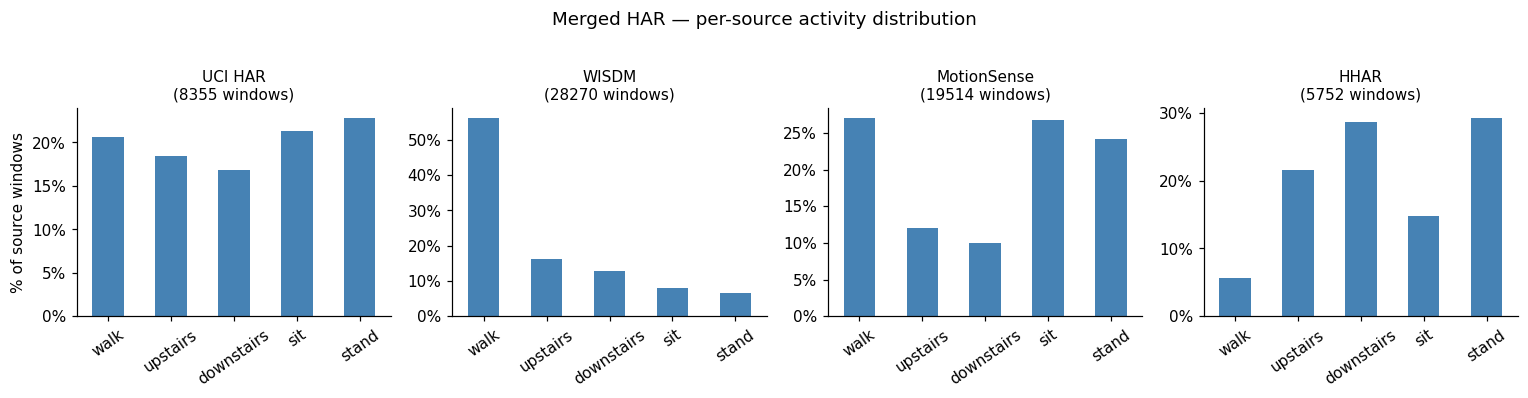

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
entries = [("UCI HAR", act_uci), ("WISDM", act_wisdm),
           ("MotionSense", act_ms), ("HHAR", act_hhar)]

for ax, (name, acts) in zip(axes, entries):
    counts = pd.Series(acts).value_counts().reindex(COMMON_ACT, fill_value=0)
    pct = counts / counts.sum() * 100
    pct.plot.bar(ax=ax, color="steelblue", rot=35)
    ax.set_title(f"{name}\n({len(acts)} windows)", fontsize=10)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}%"))
    ax.set_xlabel("")

axes[0].set_ylabel("% of source windows")
fig.suptitle("Merged HAR — per-source activity distribution", y=1.02)
plt.tight_layout()
plt.show()

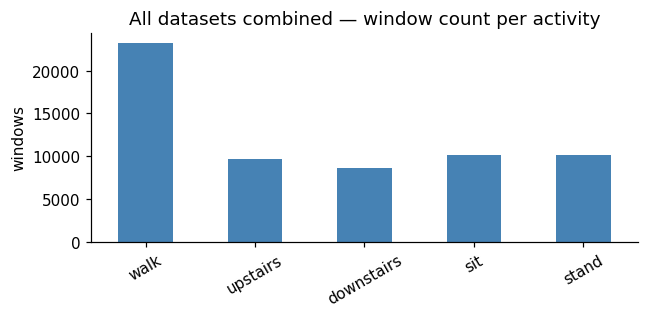

In [9]:
# Overall class balance
fig, ax = plt.subplots(figsize=(6, 3))
pd.Series(activity).value_counts().reindex(COMMON_ACT, fill_value=0).plot.bar(
    ax=ax, color="steelblue", rot=30)
ax.set_title("All datasets combined — window count per activity")
ax.set_ylabel("windows")
plt.tight_layout()
plt.show()

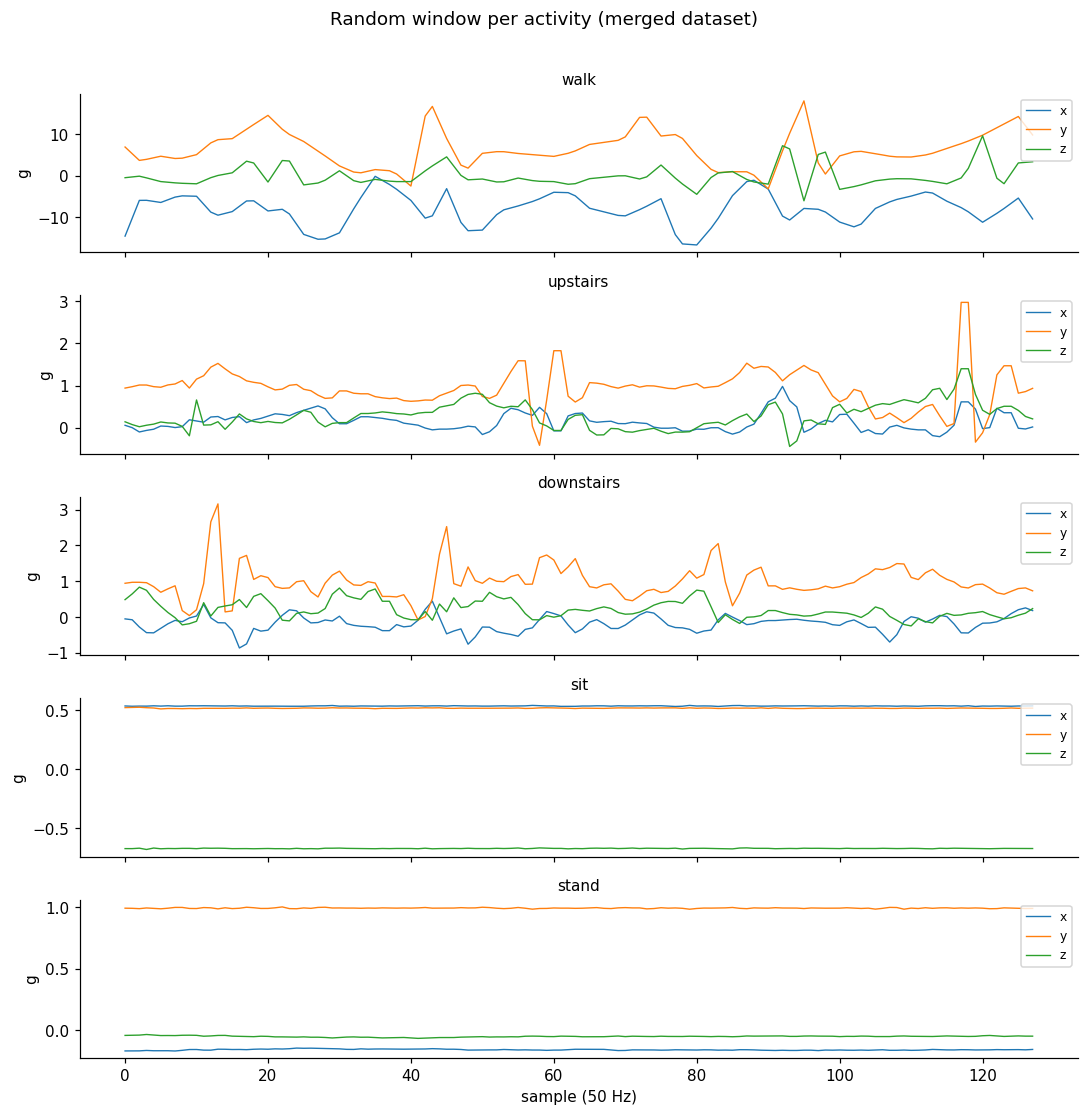

In [10]:
# Quick sanity check: plot one random window per activity
fig, axes = plt.subplots(len(COMMON_ACT), 1, figsize=(10, 10), sharex=True)
rng = np.random.default_rng(42)

for ax, act_name in zip(axes, COMMON_ACT):
    idx = np.where(activity == act_name)[0]
    if len(idx) == 0:
        ax.set_title(f"{act_name} — no samples")
        continue
    w = X[rng.choice(idx)]   # (128, 3)
    for c, col in enumerate(["x", "y", "z"]):
        ax.plot(w[:, c], label=col, linewidth=0.9)
    ax.set_title(f"{act_name}", fontsize=10)
    ax.set_ylabel("g")
    ax.legend(fontsize=8, loc="upper right")

axes[-1].set_xlabel("sample (50 Hz)")
fig.suptitle("Random window per activity (merged dataset)", y=1.01)
plt.tight_layout()
plt.show()